# Decision Analysis

## The Price is Right Problem

Two contestants guess the total value of a package of prizes. Guessing more than the prize cost causes you to lose. 

- Nate guesses 26k but the value comes in at 25,347. He loses.
- Letia guesses 21.5k and the value comes in at 21,578. She wins.
- And, because she was less than $250 off, she win's Nate's prizes as well.

For the Bayesian thinker, this poses several questions:

1. Before seeing the prizes, what prior beliefs should the contestants have about the price of the prizes?
2. After seeing the prizes, how should the contestants update those beliefs?
3. Based on the posterior distribution, what should the contestants bid?

The third question demonstrates a common use of Bayesian methods: decision analysis. 

In [9]:
import pandas as pd

def read_data(filename):
    df = pd.read_csv(filename, index_col = 0, skiprows = [1])
    return df.dropna().transpose()

In [10]:
df2011 = read_data('/Users/colelacroix/math/00.10_Think_Bayes_Downey/data/showcases.2011.csv')
df2012 = read_data('/Users/colelacroix/math/00.10_Think_Bayes_Downey/data/showcases.2012.csv')

df = pd.concat([df2011, df2012], ignore_index = True)

df.head(3)

,Showcase 1,Showcase 2,Bid 1,Bid 2,Difference 1,Difference 2
0,50969.0,45429.0,42000.0,34000.0,8969.0,11429.0
1,21901.0,34061.0,14000.0,59900.0,7901.0,-25839.0
2,32815.0,53186.0,32000.0,45000.0,815.0,8186.0


## Kernel Density Estimation

The data set above includes prices from 313 previous showcases, a good place to start when estimating a new showcase (prior). 

Using Kernel Density Estimation (KDE), we can estimate a smooth distribution. 

In [11]:
from scipy.stats import gaussian_kde
from empiricaldist import Pmf

def kde_from_sample(sample, qs):
    """ Make a kernel density estimate from a sample """
    kde = gaussian_kde(sample)
    ps = kde(qs)
    pmf = Pmf(ps, qs)
    pmf.normalize()
    return pmf

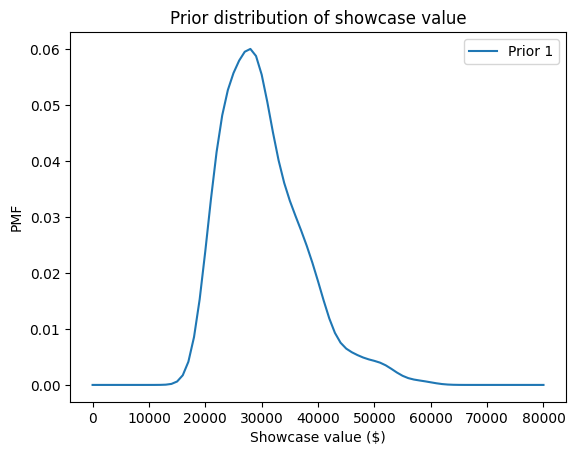

In [14]:
import numpy as np

qs = np.linspace(0, 80000, 81)
prior1 = kde_from_sample(df['Showcase 1'], qs)

import matplotlib.pyplot as plt

prior1.plot(label = 'Prior 1')
plt.xlabel('Showcase value ($)')
plt.ylabel('PMF')
plt.title('Prior distribution of showcase value')
plt.legend()
plt.show()

## Distribution of Error

Now that we have a prior, we have to decide: 

- What data should we use to update it?
- How should we quanitfy it?
- Can we compute a likelihood function? Meaning, can we comopute the conditional likelihood of the data?

To answer these questions, we model each contestant as a price-guessing instrument with known error characteristics. 

So we answer the question: If the actual price is 'price', what is the likelihood that the contestant's guess would be 'guess'?

Equivalently: what is the likelihood that the guess is off by 'error'?

In [15]:
# define 'error'

sample_diff1 = df['Bid 1'] - df['Showcase 1']
sample_diff2 = df['Bid 2'] - df['Showcase 2']

In [16]:
# visualize using KDE

qs = np.linspace(-40000, 20000, 61)
kde_diff1 = kde_from_sample(sample_diff1, qs)
kde_diff2 = kde_from_sample(sample_diff2, qs)

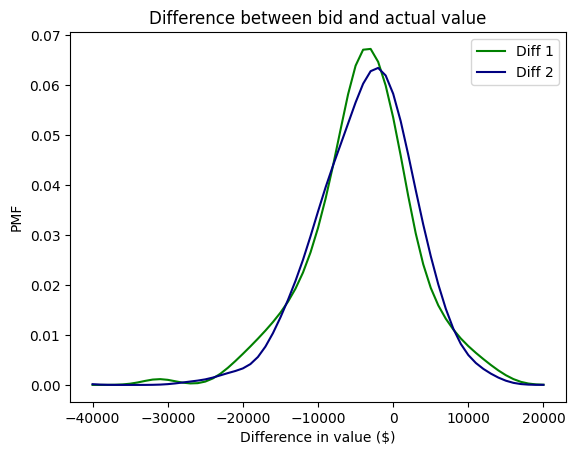

In [18]:
kde_diff1.plot(label = 'Diff 1', color = 'green')
kde_diff2.plot(label = 'Diff 2', color = 'navy')
plt.xlabel('Difference in value ($)')
plt.ylabel('PMF')
plt.title('Difference between bid and actual value')
plt.legend()
plt.show()

These distributions could be well modeled by normal distributions. So, let's summarize them with their mean and standard deviation. 

In [19]:
mean_diff1 = sample_diff1.mean()
std_diff1 = sample_diff1.std()

print(mean_diff1, std_diff1)

-4116.3961661341855 6899.909806377117


Now we can use these differences to modelt he contestants distribution of errors. But, we have to make some assumptions:

- Assume contestants underbid to be strategic, and that on average their guesses are accurate (the mean of their errors is 0).
- Assume the spread of the differences relects the sperad of their errors. So, we use the standard deviation of the differences as the standard deviation fo their errors.

Based on these assumptions, we make a normal distribution with parameters 0 and std_diff1. 

In [20]:
from scipy.stats import norm

error_dist1 = norm(0, std_diff1)

The result is a an object that provides a probability density function. 

In [21]:
# example
error = -100
error_dist1.pdf(error)

np.float64(5.781240564008691e-05)

On its own, it doesn't mean much (it's not a probability density). But they are proportional to probabilities, so we can use them as likelihoods. 

## Update

Imagine I'm player 1. I guess the value of a showcase at $23,000. From the guess we subtract each hypothetical price in the distribution, giving us the error under each hypothesis. 

In [22]:
guess1 = 23000
error1 = guess1 - prior1.qs

Suppose also that based on past performance, our estimation is well modeled by error_dist1. Under that assumption, we can compute the likelihood of your error under each hypothesis:

In [23]:
likelihood1 = error_dist1.pdf(error1)

The result is an array of likelihoods that we can use to update the prior:

In [24]:
posterior1 = prior1 * likelihood1
posterior1.normalize()

np.float64(3.3889812097254624e-05)

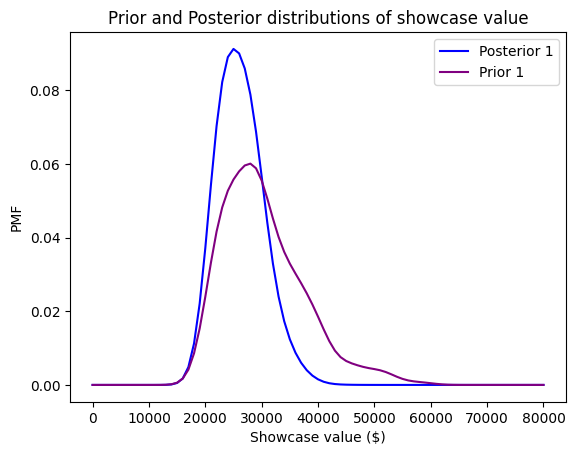

In [33]:
posterior1.plot(label = 'Posterior 1', color = 'blue')
prior1.plot(label = 'Prior 1', color = 'purple')
plt.xlabel('Showcase value ($)')
plt.ylabel('PMF')
plt.title('Prior and Posterior distributions of showcase value')
plt.legend()
plt.show()

In [52]:
# player 2

qs = np.linspace(0, 80000, 81)
prior2 = kde_from_sample(df['Showcase 2'], qs)

mean_diff2 = sample_diff2.mean()
std_diff2 = sample_diff2.std()

print(mean_diff2, std_diff2)

-3675.891373801917 6886.260711323408


In [53]:
from scipy.stats import norm

error_dist2 = norm(0, std_diff2)

In [54]:
guess2 = 38000
error2 = guess2 - prior2.qs

In [55]:
likelihood2 = error_dist2.pdf(error2)

In [56]:
posterior2 = prior2 * likelihood2
posterior2.normalize()

np.float64(2.6978123219107025e-05)

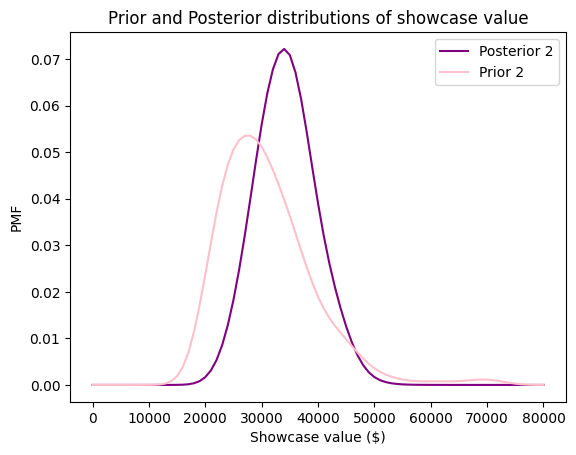

In [57]:
posterior2.plot(label = 'Posterior 2', color = 'purple')
prior2.plot(label = 'Prior 2', color = 'pink')
plt.xlabel('Showcase value ($)')
plt.ylabel('PMF')
plt.title('Prior and Posterior distributions of showcase value')
plt.legend()
plt.show()

## Probability of Winning

Now that we have posterior distributions for each player, let's strategize. 

From the perspective of Player 1, let's compute the probability that Player 2 overbids. To simplify, we only use past player performance and ignore showcase value. 

In [58]:
def prob_overbid(sample_diff):
    """ Compute the probability of overbid."""
    return np.mean(sample_diff > 0)

In [60]:
# probability of player 2 overbid
prob_overbid(sample_diff2)

np.float64(0.29073482428115016)

Now suppose that Player 1 underbids by $5,000. What is the probability taht Player 2 underbids more?

In [62]:
def prob_worse_than(diff, sample_diff):
    """" Probability opponent diff is worse than given diff."""
    return np.mean(sample_diff < diff)

In [64]:
# prob that player 2 underbids by more than $5,000

prob_worse_than(-5000, sample_diff2)

np.float64(0.38338658146964855)

In [66]:
# prob that player 2 underbids by more thank $10,000

prob_worse_than(-10000, sample_diff2)

np.float64(0.14376996805111822)